# Week2-1: 6D MCMC from scratch

Now we have the position of all the stars in the 1x1 degree on the sky. \
We assume that each star could belong ot the dwarf galaxy that follows a Gaussian distribution or a the MW forground that follows a flat distribution. \
Now we will determine the 2D distribution of dwarf galaxies on the sky, as well as the member probability of each star. 



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner

%matplotlib inline

In [3]:
data_path = '../data/Dwarfs/'
res_path = '../result/'
fig_path = '../figure/'


df = pd.read_csv(data_path+'Dwarf_02')

df

,X_pc,Y_pc,vr,d_vr,FeH,d_FeH,flag
0,76.612,-43.869,999.00,999.0,-2.36,0.30,1
1,143.351,-126.866,999.00,999.0,-1.96,0.25,1
2,65.016,-97.371,999.00,999.0,-1.75,0.25,1
3,125.190,-138.133,-182.05,4.6,-2.09,0.23,1
4,171.824,-161.871,999.00,999.0,-1.98,0.26,1
...,...,...,...,...,...,...,...
8884,1345.167,1199.917,999.00,999.0,-1.56,0.24,0
8885,-2086.182,-2769.483,999.00,999.0,-1.22,0.25,0
8886,-1265.340,2955.722,999.00,999.0,-1.17,0.28,0
8887,-3164.018,1835.498,999.00,999.0,-1.47,0.24,0


## Check the data first

The dwarf galaxy looks very elliptical, so that we need more parameters!

(-2000.0, 2000.0)

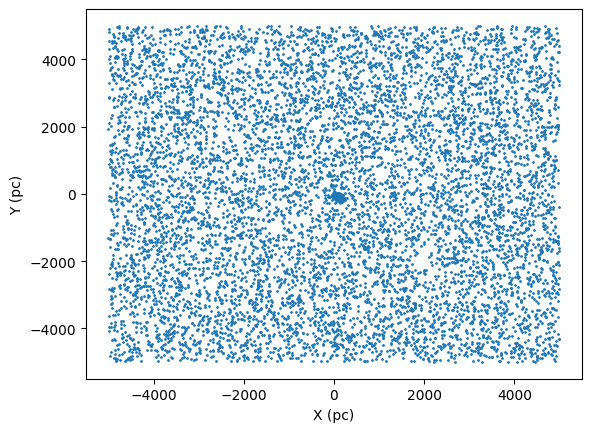

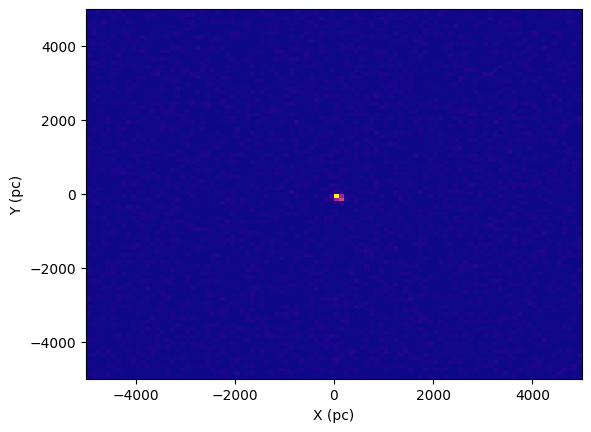

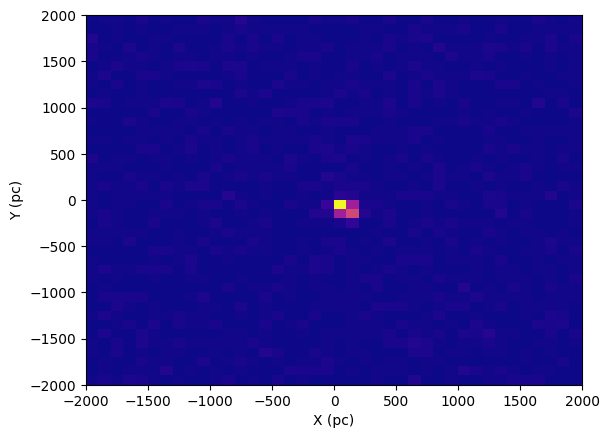

In [4]:
plt.figure()
plt.scatter(df['X_pc'], df['Y_pc'], s=1)

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.figure()
plt.hist2d(df['X_pc'], df['Y_pc'], bins=100, cmap='plasma')

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")


plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)


In [5]:
def new_coords(x, y, alpha):

    x_new = x * np.cos(alpha) + y * np.sin(alpha)
    y_new = - x * np.sin(alpha) + y * np.cos(alpha)

    return x_new, y_new

# define the two axis of the ellipse using sigma_x, sigma_y, and alpha (change within pi/2)
def log_Likelihood(theta, x, y):

    xc, yc, sigma_x, sigma_y, alpha, f = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    # Calculate the likelihood of being in the dwarf galaxy
    L1 = f/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    # Calculate the likelihood of being in the MW foreground
    L2 = (1-f)/10000**2.
    
    logL = np.sum(np.log(L1 + L2))

    return logL


In [6]:
xc0 = 0
yc0 = 0
sigma_x0 = 100
sigma_y0 = 100
alpha0 = 0
f0=0.1
param0 = xc0, yc0, sigma_x0, sigma_y0, alpha0, f0

logL0 = log_Likelihood(param0, df['X_pc'], df['Y_pc'])

# refine the following steps based on the uncertainties of the results
step_xc = 4
step_yc = 4
step_sigma_x = 2
step_sigma_y = 2
step_alpha = np.pi/60
step_f = 0.001

nsteps = 50000

samples = np.zeros((nsteps, 8))
accept = 1

In [7]:
for i in range(nsteps):

    param1 = param0
    logL1 = logL0

    samples[i, :6] = param1
    samples[i, 6] = logL1
    samples[i, 7] = accept

    accept = 0

    xc1, yc1, sigma_x1, sigma_y1, alpha1, f1 = param1
    xc1 = xc1 + np.random.normal(0, step_xc)   
    yc1 = yc1 + np.random.normal(0, step_yc)
    sigma_x1 = sigma_x1 + np.random.normal(0, step_sigma_x)
    sigma_y1 = sigma_y1 + np.random.normal(0, step_sigma_y)
    alpha1 = alpha1 + np.random.normal(0, step_alpha)

    f1 = f1 + np.random.normal(0, step_f)
    param1 = xc1, yc1, sigma_x1, sigma_y1, alpha1, f1

     # assuming the axis changing from 0 to pi/2, may need to adjust to (-pi/4 to pi/4) for some dwarfs

    if (0 < f1 < 1) & (0 <sigma_x1 < 1000) & (0 < sigma_y1 < 1000) & (0 <= alpha1 < np.pi/2) :
    
        logL1 = log_Likelihood(param1,  df['X_pc'], df['Y_pc'])      

        if logL1 > logL0:

            param0 = param1
            logL0 = logL1
            accept = 1

        else:

            a = np.random.uniform(0, 1)
            if (logL1-logL0) > np.log(a):

                param0 = param1
                logL0 = logL1
                accept = 1

In [8]:
# Check the acceptance rate of the MCMC (should be around 20%)
ind_accept = samples[:, -1] == 1
print ("Dwarf%02d acceptance rate"%2, len(samples[ind_accept, -1])/nsteps)


Dwarf02 acceptance rate 0.27436


In [9]:
samples =  samples[int(nsteps*0.1):]
np.savetxt(res_path+'Dwarf_%02d_6D_MCMC_chain.txt'%3, samples)

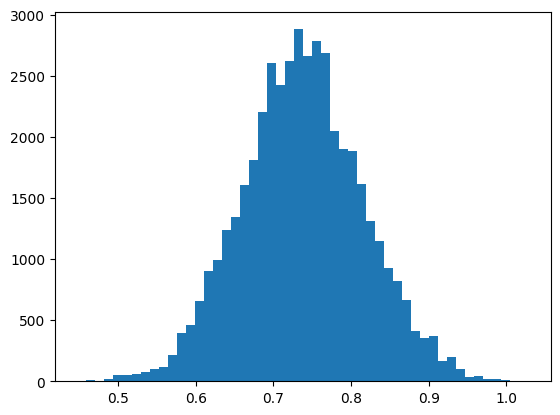

In [10]:
# Check the tilted angle first, because we may change the range of plotting
alpha_chain = samples[:,4]
plt.figure()
plt.hist(alpha_chain, bins=50);

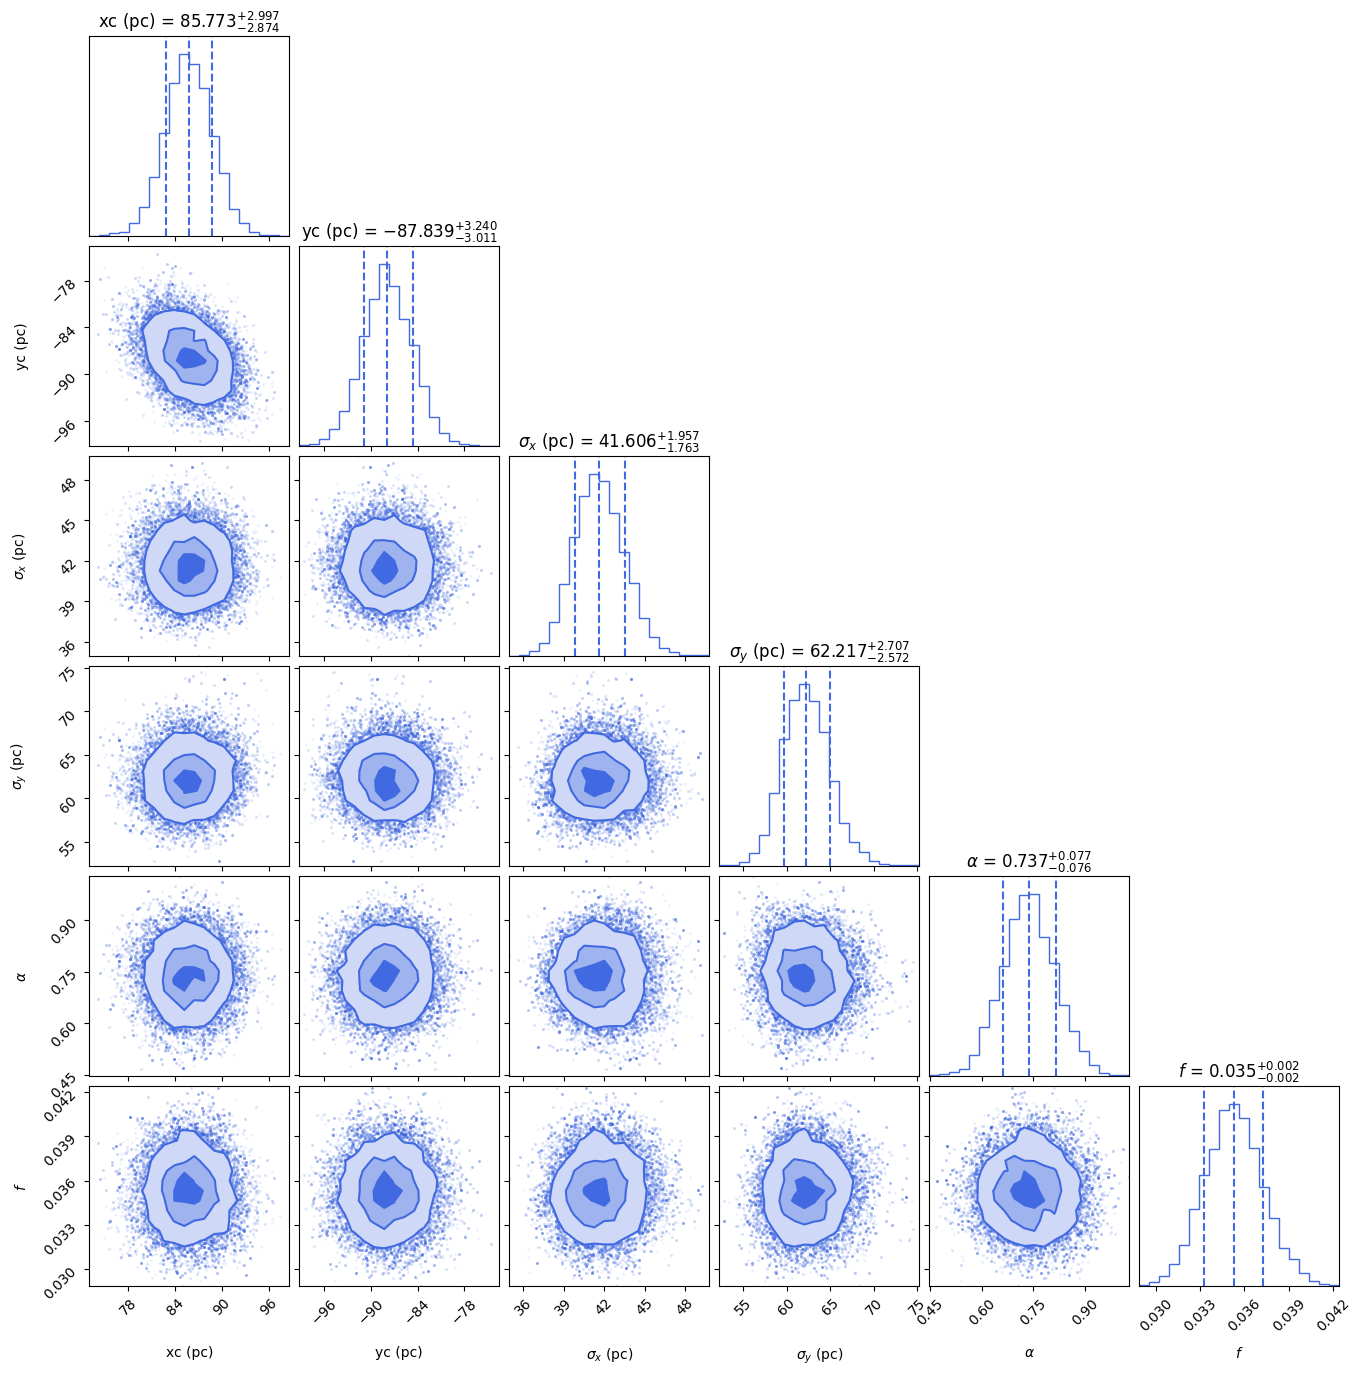

In [11]:
figure_path="../figure/"
fig = corner.corner(
    samples[:,:6],
    labels=[r"xc (pc)", r"yc (pc)", r"$\sigma_x$ (pc)", r"$\sigma_y$ (pc)", r"$\alpha$", r"$f$"],
    # truths=[mvr1_true, dvr1_true, mvr2_true, dvr2_true, f_true],  # optional
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)

plt.savefig(figure_path+'Dwarf_%02d_6D_MCMC_corner.png'%2, dpi=300)

In [12]:
# Check the ellipticity of the dwarf
sigma_x_chain = samples[:,2]
sigma_y_chain = samples[:,3]
alpha_chain = samples[:,4]
e_chain = np.fabs(1 - sigma_x_chain/sigma_y_chain)

samples_new = np.column_stack((alpha_chain, e_chain))




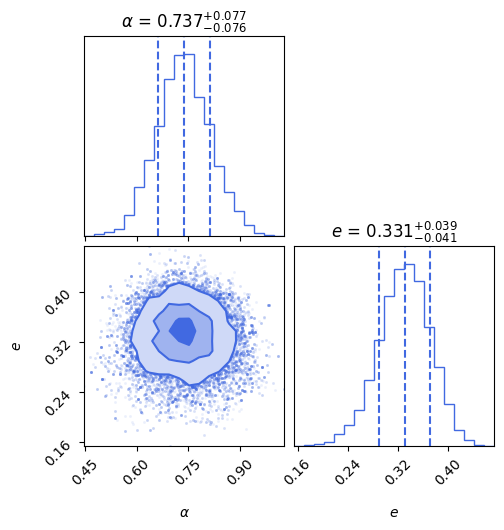

In [13]:
fig = corner.corner(
    samples_new,
    labels=[r"$\alpha$", r"$e$"],
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    levels=(0.16, 0.5, 0.84),
    color="royalblue",
    fill_contours=True
)



## Check if the model represents the data well

201 201 (200, 200)


(-1000.0, 1000.0)

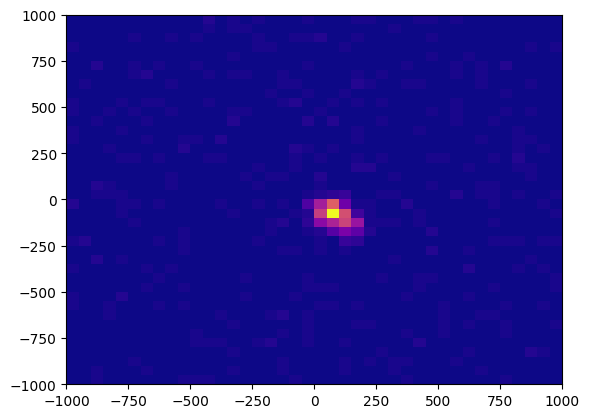

In [14]:
h, xbins, ybins = np.histogram2d(df['X_pc'], df['Y_pc'], bins=[200, 200])
print (len(xbins), len(ybins), h.shape)
plt.figure()
poly = plt.pcolormesh(xbins, ybins, h.T, cmap='plasma');
plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)


In [15]:
param_f = np.zeros(6)
for i in range(6):

    param_f[i] = np.percentile(samples[:,i], 50)
print (param_f)

L_bin = np.zeros((200, 200))
xc_bin =(xbins[:-1] + xbins[1:])*0.5
yc_bin =(ybins[:-1] + ybins[1:])*0.5

for i in range(200):

    for j in range(200):
                   
        L_bin[i, j] = np.exp(log_Likelihood(param_f, xc_bin[i], yc_bin[j])) * (10000/200)**2. * len(df)

[ 8.57731929e+01 -8.78387855e+01  4.16063156e+01  6.22168259e+01
  7.36745640e-01  3.52732317e-02]


(-1000.0, 1000.0)

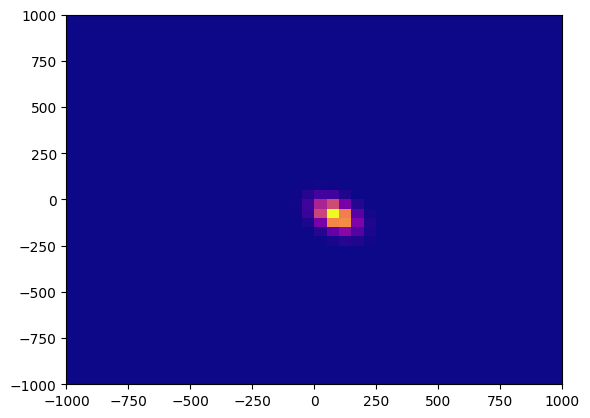

In [16]:
plt.figure()
poly = plt.pcolormesh(xbins, ybins, L_bin.T, cmap='plasma');

plt.xlim(-1000, 1000)
plt.ylim(-1000, 1000)

## Calculating the membership probabilities

In [17]:
def prob_member(theta, x, y):

    xc, yc, sigma_x, sigma_y, alpha, f = theta

    x1, y1 = new_coords(x, y, alpha)
    xc1, yc1 = new_coords(xc, yc, alpha)

    # Calculate the likelihood of being in the dwarf galaxy
    p1 = 1/(2*np.pi*sigma_x * sigma_y)*np.exp(-0.5*((x1-xc1)**2./sigma_x**2.+(y1-yc1)**2./sigma_y**2.))
    # Calculate the likelihood of being in the MW foreground
    p2 = 1/10000**2.
    
    prob = p1 / (p1 + p2)

    return prob


In [35]:
ind_max = np.argmax(samples[:,-2])
param_best = samples[ind_max,:6]

print (param_best)


p_member1 = np.zeros(len(df))

p_member1 = prob_member(param_best, df['X_pc'], df['Y_pc'])


[ 8.63656750e+01 -8.82118675e+01  4.16078569e+01  6.23409546e+01
  7.64365899e-01  3.56395011e-02]


In [36]:
p_member2 = np.zeros(len(df))

for i in range(len(samples)):

    param = samples[i,:6]
    p_member2 += prob_member(param, df['X_pc'], df['Y_pc'])

p_member2 = p_member2/len(samples)



Text(0, 0.5, 'Pmember (marginalized over all models)')

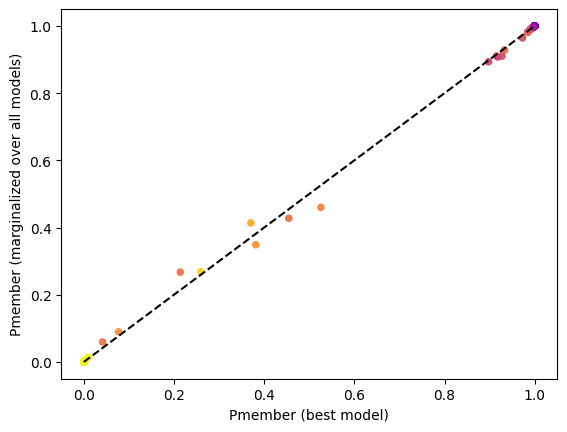

In [55]:
plt.figure()
plt.scatter(p_member1, p_member2, c=np.sqrt((df["X_pc"]-param_best[0])**2.+(df["Y_pc"]-param_best[1])**2.), s=20, cmap="plasma", vmin=0, vmax=300)

plt.plot((0,1), (0,1), color="k", ls= "dashed")
plt.xlabel("Pmember (best model)")
plt.ylabel("Pmember (marginalized over all models)")

In [38]:
df['P_member_position'] = p_member2

Text(0.5, 0, 'Probability of being a member of Dwarf02')

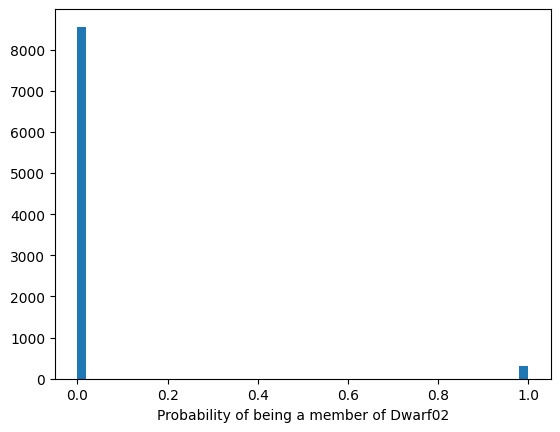

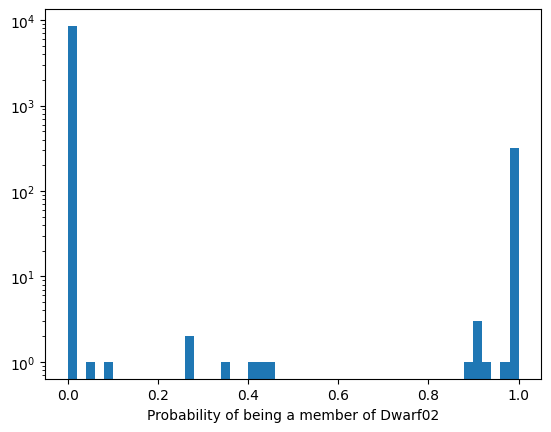

In [39]:
plt.figure()
plt.hist(p_member2, bins=50);
plt.xlabel("Probability of being a member of Dwarf%02d"%2)

plt.figure()
plt.hist(p_member2, bins=50);
plt.yscale("log")
plt.xlabel("Probability of being a member of Dwarf%02d"%2)

(-2000.0, 2000.0)

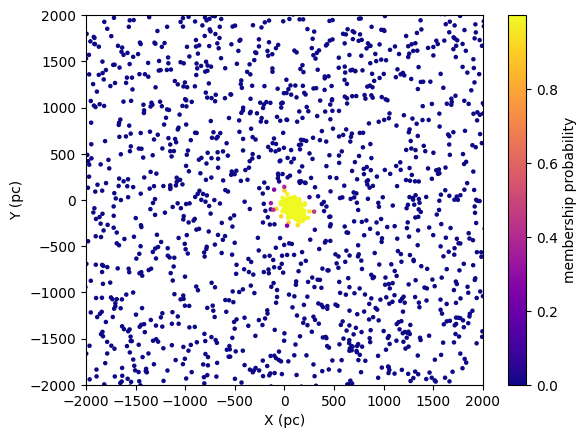

In [40]:
plt.figure()
im=plt.scatter(df['X_pc'], df['Y_pc'], c=df['P_member_position'], s=5, cmap='plasma')
cb=plt.colorbar(im)
cb.set_label("membership probability")

plt.xlabel("X (pc)")
plt.ylabel("Y (pc)")

plt.xlim(-2000, 2000)
plt.ylim(-2000, 2000)